In [67]:
import sys
import os

sys.path.append(os.path.abspath(".."))  # or "." depending on location

In [68]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score


from src.pipeline import build_pipeline

In [69]:
df = pd.read_csv("https://raw.githubusercontent.com/ananyaghorpade29/titanic/refs/heads/main/data/Titanic-Dataset.csv")
df.head()
x= df.drop(["Survived", "Name", "Ticket", "Cabin", "PassengerId"], axis=1)
y= df["Survived"]

OneHotEncoder(handle_unknown="ignore", sparse_output=False)

categorical_cols = ["Sex", "Embarked"]
numerical_cols = ["Age", "Fare", "Pclass", "SibSp", "Parch"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols),
])

pipelines = {
    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(eval_metric='logloss', random_state=42))
    ]),
    
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(random_state=42))
    ])
}

x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=42)

for name, pipe in pipelines.items():
    print(f"Training {name}...")
    pipe.fit(x_train, y_train)
    
for name, pipe in pipelines.items():
    y_pred = pipe.predict(x_test)
    print(f"{name} predictions done")


Training RandomForest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 202
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [70]:
#tuning models
# Store results
best_models = {}


# Random Forest
param_grid_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    estimator=pipelines["RandomForest"],
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    verbose=1,
    n_jobs=-1
)
grid_rf.fit(x_train, y_train)

print("\n RandomForest Best Params:", grid_rf.best_params_)
print(" RandomForest Best Score:", grid_rf.best_score_)

best_models["RandomForest"] = grid_rf.best_estimator_


# LightGBM (BEST MODEL)
param_grid_lgbm = {
    "model__num_leaves": [20, 31, 50],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": [100, 200, 300]
}

grid_lgbm = GridSearchCV(
    estimator=pipelines["LightGBM"],
    param_grid=param_grid_lgbm,
    cv=5,
    scoring="f1",
    verbose=1,
    n_jobs=-1
)
grid_lgbm.fit(x_train, y_train)

print("\n LightGBM Best Params:", grid_lgbm.best_params_)
print(" LightGBM Best Score:", grid_lgbm.best_score_)

best_models["LightGBM"] = grid_lgbm.best_estimator_



# XGBoost

param_grid_xgb = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__n_estimators": [100, 200]
}

grid_xgb = GridSearchCV(
    estimator=pipelines["XGBoost"],
    param_grid=param_grid_xgb,
    cv=5,
    scoring="f1",
    verbose=1,
    n_jobs=-1
)
grid_xgb.fit(x_train, y_train)

print("\nXGBoost Best Params:", grid_xgb.best_params_)
print(" XGBoost Best Score:", grid_xgb.best_score_)

best_models["XGBoost"] = grid_xgb.best_estimator_
print("Best CV Score: ",grid_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits

 RandomForest Best Params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
 RandomForest Best Score: 0.7449666017622171
Fitting 5 folds for each of 27 candidates, totalling 135 fits
[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000160 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 202
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838

 LightGBM Best Params: {'model__learning_rate': 0.1, 'model__n_estimators': 100, 'model__num_leaves': 20}
 LightGBM Best Score: 0.7552318123511087
Fitting 5 folds for

In [71]:
best_params= {
    k.replace("model__",""):v
    for k,v in grid_search.best_params_.items()
}

In [72]:
#model define
rf_model = grid_search.best_estimator_
xgb_model = XGBClassifier(use_label_encoder=False,random_state=42)
lgbm_model= LGBMClassifier(random_state=42)

In [73]:
#build pipeline
rf_pipeline= build_pipeline(rf_model)
xgb_pipeline= build_pipeline(xgb_model)
lgbm_pipeline= build_pipeline(lgbm_model)

In [74]:
print(grid_search.best_params_)

{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [75]:
#Evaluate with 5-Fold CV
scoring = ["accuracy", "f1"]
models = {
    "RandomForest(Tuned)": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]),
      
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("model",LGBMClassifier())
    ])
}
results=[]

for name,model in models.items():
    scores = cross_validate(model, x_train, y_train, cv=5, scoring=scoring)
    
    results.append({
        "Model":name,
        "Accuracy": scores["test_accuracy"].mean(),
        "F1 Score": scores["test_f1"].mean()
    })
    
results_df = pd.DataFrame(results)
print(results_df)


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [14:15:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [14:15:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [14:15:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are

[LightGBM] [Info] Number of positive: 214, number of negative: 355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 187
[LightGBM] [Info] Number of data points in the train set: 569, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376098 -> initscore=-0.506142
[LightGBM] [Info] Start training from score -0.506142
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 215, number of negative: 355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 188
[LightGBM] [Info] Number of data points in the train set: 570, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.377193 -> initscore=-0.501480
[LightGBM] [Info] Start training from score -0.501480
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 214, number of negative: 356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 188
[LightGBM] [Info] Number of data points in the train set: 570, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375439 -> initscore=-0.508955
[LightGBM] [Info] Start training from score -0.508955
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [76]:
#Add previous models (TOTAL=5 models)
models.update({
    "Logistic Regression": build_pipeline(LogisticRegression(max_iter=1000)),
    "Decison Trees": build_pipeline(DecisionTreeClassifier(random_state=42)),
    "Random Forest(Baseline)":build_pipeline(RandomForestClassifier(random_state=42))
})


In [77]:
#result table
results=[]

for name,model in models.items():
    scores= cross_validate(model, x_train, y_train, cv=5, scoring=scoring)
    
    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "F1 score": scores["test_f1"].mean()
    })
    
    
results_df= pd.DataFrame(results).sort_values(by="F1 score",ascending=False)
print(results_df)

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [14:15:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [14:15:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [14:15:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are

[LightGBM] [Info] Number of positive: 214, number of negative: 355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 187
[LightGBM] [Info] Number of data points in the train set: 569, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376098 -> initscore=-0.506142
[LightGBM] [Info] Start training from score -0.506142
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                     Model  Accuracy  F1 score
2                 LightGBM  0.820221  0.752914
1                  XGBoost  0.799183  0.729267
5  Random Forest(Baseline)  0.797804  0.728089
0      RandomForest(Tuned)  0.789373  0.719575
3      Logistic Regression  0.790663  0.706348
4            Decison Trees  0.748646  0.674276


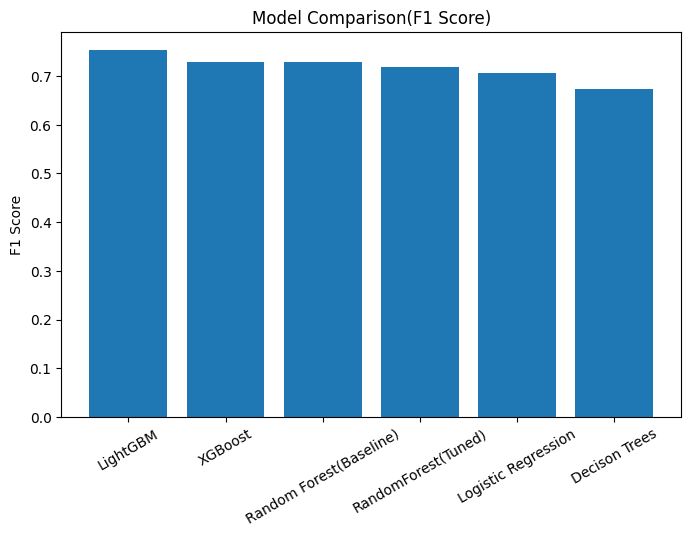

In [78]:
#visualize
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["F1 score"])

plt.xticks(rotation=30)
plt.title('Model Comparison(F1 Score)')
plt.ylabel("F1 Score")
plt.show()

GridSearchCV tuning for RandomForest, best params + accuracy heatmap
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10]
}
grid = GridSearchCV(full_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_, grid.best_score_)

add XGBoost + LightGBM, updated 5-model comparison chart
XGBoost and LightGBM are what people actually use at internships and jobs for tabular data. Getting comfortable with them now puts you ahead of most ML beginners.